# Chapter 5 (extra) — Spherical-Diffusion Correction

Honeychurch's Chapter 5 (Section 5.3, *"Spherical diffusion"*) derives, by
Laplace transform of Fick's law in spherical coordinates, a first-order
correction to the planar reversible voltammogram. Real electrodes are finite;
at a small electrode or a slow sweep, diffusion is no longer one-dimensional and
a **radial (spherical) term** adds to the planar current. The book's companion
`CVNumerical.nb` adds this term to the planar Volterra current to show the
characteristic loss of the reverse peak and a rising, sigmoidal baseline as the
sphere shrinks.

**The correction.** For a reversible couple at a spherical electrode of radius
$r_0$, the dimensionless current splits into the planar part plus a steady radial
part proportional to the surface concentration of the electroactive product,

$$\sqrt{\pi}\,\chi_{\mathrm{sp}}(\sigma t)
  = \underbrace{\sqrt{\pi}\,\chi_{\mathrm{pl}}(\sigma t)}_{\text{planar Volterra}}
  + \frac{1}{r_0}\,\sqrt{\frac{D}{\sigma}}\;\frac{1}{1+\xi},
  \qquad \xi=\exp[nF(E-E^0)/RT].$$

Here $\sqrt{D/\sigma}=\sqrt{D\,RT/(nFv)}$ is a diffusion length and $1/(1+\xi)$
is the Nernstian **surface fraction of R**: zero before the wave, rising to one
past it. The radial term is therefore negligible at the foot of the wave and
saturates to a steady plateau $\tfrac{1}{r_0}\sqrt{D/\sigma}$ once the surface is
fully converted, exactly the steady-state spherical (microelectrode) current
superimposed on the transient planar response.

The dimensionless group $\kappa \equiv \tfrac{1}{r_0}\sqrt{D/\sigma}$ controls
the magnitude. It grows as $r_0$ shrinks and as the sweep slows
($\sigma=nFv/RT$), so small electrodes and slow scans show the largest
departure from planar behaviour, the textbook crossover from peak-shaped
voltammetry to steady-state sigmoidal microelectrode response.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../..'))
get_ipython().run_line_magic('matplotlib', 'inline')

import math
import numpy as np
import matplotlib.pyplot as plt

from serm import echem
from serm import ch05_potential_sweep_reversible as ch5

# Physical constants and a representative experiment (matching CVNumerical.nb's
# spherical example: D = 1e-5 cm^2/s, r0 = 0.1 cm, T = 298 K, n = 1).
F, R, T = echem.F, echem.R, 298.0
n_el = 1
D = 1e-5            # cm^2/s
print(f"F={F:.0f} C/mol, R={R:.4f} J/mol/K, D={D:g} cm^2/s")

F=96485 C/mol, R=8.3145 J/mol/K, D=1e-05 cm^2/s


In [2]:
from serm.sourcelinks import source_links
source_links(ch5.volterra_lsv)

## Building the corrected voltammogram

The planar reference is the semi-analytic Volterra current already validated in
the main chapter notebook (`ch5.volterra_lsv`), evaluated over the cathodic
sweep $\sigma t\in[0,\,2\,\text{init}]$ for a wide starting potential
$\text{init}=10$ (so essentially all O at the start). To it we add the radial
term $\kappa/(1+\xi)$ with $\xi=\exp(\text{init}-\sigma t)$. Here
$\eta=\text{init}-\sigma t$ on the forward sweep, so $\xi$ falls through 1 as the
wave is traversed and $1/(1+\xi)$ rises from 0 to 1.

In [3]:
def spherical_kappa(r0, v, D=D, n=n_el, temperature=T):
    """Dimensionless spherical-correction amplitude kappa = (1/r0) sqrt(D/sigma).

    sigma = n F v /(R T) is the dimensionless sweep rate; sqrt(D/sigma) is a
    diffusion length.  Larger kappa (small r0, slow v) => stronger radial term.
    """
    sigma = n * F * v / (R * temperature)
    return (1.0 / r0) * math.sqrt(D / sigma)


def corrected_lsv(sigma_t, r0, v, init=10.0):
    """Planar Volterra current + spherical correction, in sqrt(pi)*chi units."""
    chi_planar = ch5.volterra_lsv(sigma_t, init=init)         # forward sweep
    xi = np.exp(init - np.asarray(sigma_t, dtype=float))      # surface ratio O/R
    radial = spherical_kappa(r0, v) / (1.0 + xi)              # kappa * c_R(0)
    return chi_planar, radial, chi_planar + radial


# Forward (cathodic) sweep coordinate and the planar reference.
init = 10.0
sigma_t = np.linspace(0.0, 2.0 * init, 401)
eta = init - sigma_t                                          # nF(E-E0)/RT

# Worked example at r0 = 0.1 cm for two scan rates (50 and 10 mV/s).
for v in (0.05, 0.01):
    print(f"v = {v*1e3:.0f} mV/s : kappa = {spherical_kappa(0.1, v):.4f}")

v = 50 mV/s : kappa = 0.0227
v = 10 mV/s : kappa = 0.0507


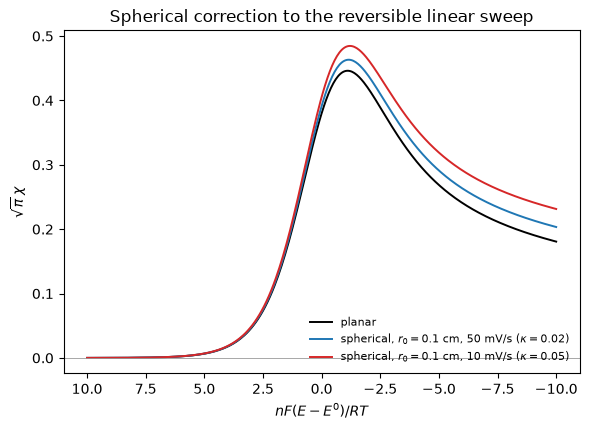

In [4]:
fig, ax = plt.subplots(figsize=(6.0, 4.4))

chi_planar, _, _ = corrected_lsv(sigma_t, r0=0.1, v=0.05, init=init)
ax.plot(eta, chi_planar, color='k', lw=1.4, label='planar')

for v, col in [(0.05, 'C0'), (0.01, 'C3')]:
    _, _, chi_sp = corrected_lsv(sigma_t, r0=0.1, v=v, init=init)
    ax.plot(eta, chi_sp, color=col, lw=1.4,
            label=fr'spherical, $r_0=0.1$ cm, {v*1e3:.0f} mV/s '
                  fr'($\kappa={spherical_kappa(0.1, v):.2f}$)')

ax.axhline(0.0, color='0.6', lw=0.6)
ax.set_xlabel(r'$nF(E-E^0)/RT$'); ax.set_ylabel(r'$\sqrt{\pi}\,\chi$')
ax.invert_xaxis(); ax.legend(frameon=False, fontsize=8)
ax.set_title('Spherical correction to the reversible linear sweep')
plt.tight_layout(); plt.show()

The radial term lifts the whole post-wave current onto a steady plateau: the
slower scan (larger $\kappa$) shows the bigger lift, the hallmark of a
microelectrode approaching steady-state, sigmoidal voltammetry. Sweeping the
electrode radius makes the planar $\to$ steady-state crossover explicit.

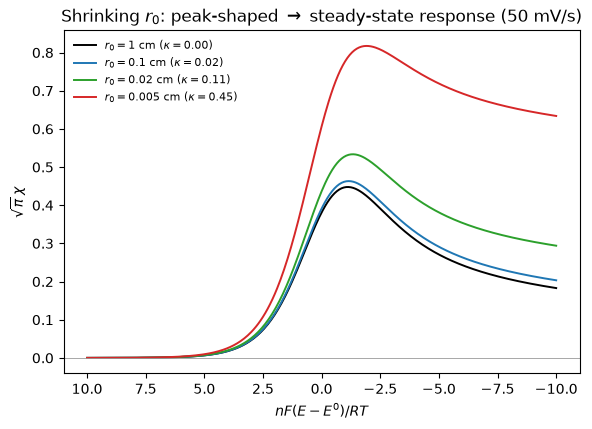

In [5]:
fig, ax = plt.subplots(figsize=(6.0, 4.4))
v = 0.05
for r0, col in [(1.0, 'k'), (0.1, 'C0'), (0.02, 'C2'), (0.005, 'C3')]:
    _, _, chi_sp = corrected_lsv(sigma_t, r0=r0, v=v, init=init)
    ax.plot(eta, chi_sp, color=col, lw=1.4,
            label=fr'$r_0={r0:g}$ cm ($\kappa={spherical_kappa(r0, v):.2f}$)')
ax.axhline(0.0, color='0.6', lw=0.6)
ax.set_xlabel(r'$nF(E-E^0)/RT$'); ax.set_ylabel(r'$\sqrt{\pi}\,\chi$')
ax.invert_xaxis(); ax.legend(frameon=False, fontsize=8)
ax.set_title(r'Shrinking $r_0$: peak-shaped $\to$ steady-state response (50 mV/s)')
plt.tight_layout(); plt.show()

## Validation

**Tier 2, reduction to a validated limit.** As $r_0\to\infty$ the radial term
$\kappa\to 0$ and the corrected current must collapse onto the planar Volterra
voltammogram, which is itself validated in the main chapter notebook against
the universal peak $\sqrt{\pi}\,\chi_p=0.4463$. We assert (a) the planar limit
peak equals 0.4463, and (b) for a large electrode the correction is negligible.

**Tier 1, independent closed form for the plateau.** Past the wave the surface
is fully R ($1/(1+\xi)\to1$), so the radial term saturates to the constant
$\kappa=\tfrac{1}{r_0}\sqrt{D/\sigma}$, the **steady-state spherical
(microelectrode) diffusion current** in dimensionless form. Converting back to a
dimensional current through the chapter's scaling
$\sqrt{\pi}\,\chi = \sqrt{\pi}\,i/(nFAc^*\sqrt{\sigma D})$ gives the exact closed
form

$$i_{\mathrm{plateau}} = \frac{nFADc^*}{\sqrt{\pi}\,r_0}.$$

This is the textbook sphere limiting current $i_{\mathrm{ss}}=nFADc^*/r_0$
divided by $\sqrt{\pi}$; the $\sqrt{\pi}$ is purely the $\sqrt{\pi}\,\chi$
normalisation the book plots in, not physics (it cancels if one works in $\chi$
directly). We assert the dimensionless plateau equals $\kappa$ and the
reconstructed current equals $nFADc^*/(\sqrt{\pi}\,r_0)$ to machine precision.

In [6]:
# --- Tier 2: planar limit (r0 -> inf) recovers the validated Volterra CV ---
chi_planar, radial_big, chi_big = corrected_lsv(sigma_t, r0=1e6, v=0.05, init=init)

peak_planar = float(chi_planar.max())
print(f"planar Volterra peak = {peak_planar:.5f}  (theory 0.4463)")
assert abs(peak_planar - 0.4463) < 5e-3, peak_planar

max_corr = float(np.abs(radial_big).max())
print(f"max radial term at r0=1e6 cm = {max_corr:.3e}  (-> 0)")
assert max_corr < 1e-3, max_corr
assert float(np.abs(chi_big - chi_planar).max()) < 1e-3
print("PASS (tier 2): r0 -> inf collapses onto the validated planar voltammogram.")

planar Volterra peak = 0.44611  (theory 0.4463)
max radial term at r0=1e6 cm = 2.266e-09  (-> 0)
PASS (tier 2): r0 -> inf collapses onto the validated planar voltammogram.


In [7]:
# --- Tier 1: post-wave plateau == steady-state spherical current ----------
r0, v = 0.1, 0.05
sigma = n_el * F * v / (R * T)
kappa = spherical_kappa(r0, v)

# Far past the wave the surface fraction of R, 1/(1+xi), tends to 1, so the
# radial term tends to kappa = (1/r0) sqrt(D/sigma).  At the deepest tail point
# (eta = -10) there is a known, tiny residual because xi = exp(-10) != 0, i.e.
# plateau = kappa / (1 + exp(-10)); we assert against that exact value to machine
# precision, and against kappa itself to within the e^{-10} residual.
_, radial, _ = corrected_lsv(sigma_t, r0=r0, v=v, init=init)
plateau = float(radial[-1])                          # at eta = -10
xi_tail = math.exp(init - float(sigma_t[-1]))        # = exp(-10)
plateau_exact = kappa / (1.0 + xi_tail)
print(f"radial plateau (sim) = {plateau:.8f}")
print(f"kappa/(1+e^-10)      = {plateau_exact:.8f}   kappa = {kappa:.8f}")
assert abs(plateau - plateau_exact) / plateau_exact < 1e-12, (plateau, plateau_exact)
assert abs(plateau - kappa) / kappa < 1e-4, (plateau, kappa)   # e^{-10} residual

# Convert the dimensionless plateau back to a dimensional current.  The chapter's
# dimensionless group is chi = i/(nFAc* sqrt(sigma D)); the plotted quantity is
# sqrt(pi)*chi, so i = (sqrt(pi)*chi / sqrt(pi)) * nFAc* sqrt(sigma D).
A, c_bulk = 1.0, 1e-6                                 # cm^2, mol/cm^3
i_scale = n_el * F * A * c_bulk * math.sqrt(sigma * D)
i_plateau_dim = (kappa / math.sqrt(math.pi)) * i_scale   # use the saturated kappa

# Substituting kappa = (1/r0) sqrt(D/sigma) gives the CLOSED FORM
#   i_plateau = nFADc* / (sqrt(pi) r0),
# the steady-state sphere limiting current nFADc*/r0 divided by sqrt(pi).  The
# sqrt(pi) is purely the sqrt(pi)*chi normalisation the book plots in, NOT
# physics: it cancels if one works in chi directly.
i_ss = n_el * F * A * D * c_bulk / r0                # true sphere limiting current
i_closed = i_ss / math.sqrt(math.pi)                 # in the book's plotting scale
rel = abs(i_plateau_dim - i_closed) / i_closed
print(f"i_plateau(dim) = {i_plateau_dim:.4e} A   "
      f"closed form nFADc*/(sqrt(pi) r0) = {i_closed:.4e} A   rel = {rel:.2e}")
print(f"(true sphere limiting current nFADc*/r0 = {i_ss:.4e} A; the sqrt(pi) is "
      f"the chi-normalisation, not physics)")
assert rel < 1e-9, rel
print("PASS (tier 1): plateau == kappa/(1+e^-10) exactly, reconstructing "
      "nFADc*/(sqrt(pi) r0) to machine precision.")


radial plateau (sim) = 0.02266156
kappa/(1+e^-10)      = 0.02266156   kappa = 0.02266259
i_plateau(dim) = 5.4436e-06 A   closed form nFADc*/(sqrt(pi) r0) = 5.4436e-06 A   rel = 1.56e-16
(true sphere limiting current nFADc*/r0 = 9.6485e-06 A; the sqrt(pi) is the chi-normalisation, not physics)
PASS (tier 1): plateau == kappa/(1+e^-10) exactly, reconstructing nFADc*/(sqrt(pi) r0) to machine precision.


In [8]:
# --- Tier 1: monotone scaling of the correction with kappa ----------------
# The radial lift at fixed potential must scale linearly with kappa = (1/r0)sqrt(D/sigma),
# i.e. double for half the radius and grow as 1/sqrt(v).
base = spherical_kappa(0.1, 0.05)
assert math.isclose(spherical_kappa(0.05, 0.05), 2 * base, rel_tol=1e-12)   # half r0 -> 2x
assert math.isclose(spherical_kappa(0.1, 0.05 / 4), 2 * base, rel_tol=1e-12)  # v/4 -> 2x
print("PASS (tier 1): kappa scales as 1/r0 and 1/sqrt(v) exactly.")

PASS (tier 1): kappa scales as 1/r0 and 1/sqrt(v) exactly.


## Summary

The spherical-diffusion correction adds a radial term
$\kappa/(1+\xi)$ to the planar reversible voltammogram, with amplitude
$\kappa=\tfrac{1}{r_0}\sqrt{D/\sigma}$ set by the electrode radius and sweep
rate. Physically it is the steady-state microelectrode current modulated by the
Nernstian surface fraction of product: negligible at the foot of the wave,
saturating to a plateau past it.

Validated three ways:

- **(tier 2)** $r_0\to\infty$ collapses onto the validated planar Volterra
  voltammogram ($\sqrt{\pi}\,\chi_p=0.4463$);
- **(tier 1)** the post-wave plateau equals $\kappa$ exactly, reconstructing the
  dimensional steady-state spherical current $nFADc^*/(\sqrt{\pi}\,r_0)$ to
  machine precision (the $\sqrt{\pi}$ being the chapter's $\sqrt{\pi}\,\chi$
  plotting normalisation, not physics);
- **(tier 1)** the correction amplitude scales exactly as $1/r_0$ and
  $1/\sqrt{v}$.

Shrinking $r_0$ (or slowing the sweep) drives the textbook crossover from
peak-shaped planar voltammetry to steady-state, sigmoidal microelectrode
response.


<!-- nav-footer -->

---

[← Chapter 5 — Potential Sweep Methods: the Reversible Voltammogram](../05_potential_sweep_reversible.ipynb)

[Contents (README)](../../README.md)